In [2]:
import torch

def explain_offset_alignment():
    """解释为什么logits和labels要错位"""
    
    # 假设我们有一个简单的句子
    sentence = "Hello world !"
    tokens = ["<bos>", "Hello", "world", "!", "<eos>"]
    token_ids = [1, 101, 102, 103, 2]  # 假设的token ID
    
    print("🎯 语言模型预测任务示例")
    print("="*60)
    print(f"原句: {sentence}")
    print(f"Tokens: {tokens}")
    print(f"Token IDs: {token_ids}")
    
    print(f"\n📊 模型的预测任务:")
    print(f"{'输入位置':<10} {'输入Token':<10} {'预测目标':<10} {'说明':<20}")
    print("-" * 60)
    
    for i in range(len(tokens) - 1):
        input_context = " ".join(tokens[:i+1])
        target_token = tokens[i+1]
        print(f"{i:<10} {tokens[i]:<10} {target_token:<10} 基于'{input_context}'预测")
    
    print(f"\n🔍 张量维度分析:")
    batch_size = 2
    seq_len = len(token_ids)
    vocab_size = 1000
    
    # 模拟输入数据
    input_ids = torch.tensor([token_ids, token_ids])  # [batch, seq]
    print(f"input_ids shape: {input_ids.shape} = [batch={batch_size}, seq={seq_len}]")
    
    # 模型输出logits
    logits = torch.randn(batch_size, seq_len, vocab_size)
    print(f"logits shape: {logits.shape} = [batch={batch_size}, seq={seq_len}, vocab={vocab_size}]")
    
    # 关键：为什么要 logits[:, :-1, :]
    prediction_logits = logits[:, :-1, :]  # 去掉最后一个位置
    print(f"prediction_logits shape: {prediction_logits.shape} = [batch={batch_size}, seq={seq_len-1}, vocab={vocab_size}]")
    
    # 关键：为什么要 input_ids[:, 1:]
    labels = input_ids[:, 1:]  # 去掉第一个位置
    print(f"labels shape: {labels.shape} = [batch={batch_size}, seq={seq_len-1}]")
    
    print(f"\n🎯 对齐关系:")
    print(f"{'位置':<8} {'输入Token':<12} {'Logits预测':<15} {'标签(真实)':<12} {'预测任务':<20}")
    print("-" * 80)
    
    for i in range(seq_len - 1):
        input_token = tokens[i]
        predicted_pos = f"logits[{i}]"
        true_token = tokens[i + 1]
        task = f"用{input_token}预测{true_token}"
        print(f"{i:<8} {input_token:<12} {predicted_pos:<15} {true_token:<12} {task:<20}")

# 运行解释
explain_offset_alignment()


🎯 语言模型预测任务示例
原句: Hello world !
Tokens: ['<bos>', 'Hello', 'world', '!', '<eos>']
Token IDs: [1, 101, 102, 103, 2]

📊 模型的预测任务:
输入位置       输入Token    预测目标       说明                  
------------------------------------------------------------
0          <bos>      Hello      基于'<bos>'预测
1          Hello      world      基于'<bos> Hello'预测
2          world      !          基于'<bos> Hello world'预测
3          !          <eos>      基于'<bos> Hello world !'预测

🔍 张量维度分析:
input_ids shape: torch.Size([2, 5]) = [batch=2, seq=5]
logits shape: torch.Size([2, 5, 1000]) = [batch=2, seq=5, vocab=1000]
prediction_logits shape: torch.Size([2, 4, 1000]) = [batch=2, seq=4, vocab=1000]
labels shape: torch.Size([2, 4]) = [batch=2, seq=4]

🎯 对齐关系:
位置       输入Token      Logits预测        标签(真实)       预测任务                
--------------------------------------------------------------------------------
0        <bos>        logits[0]       Hello        用<bos>预测Hello       
1        Hello        logits[1]       world 

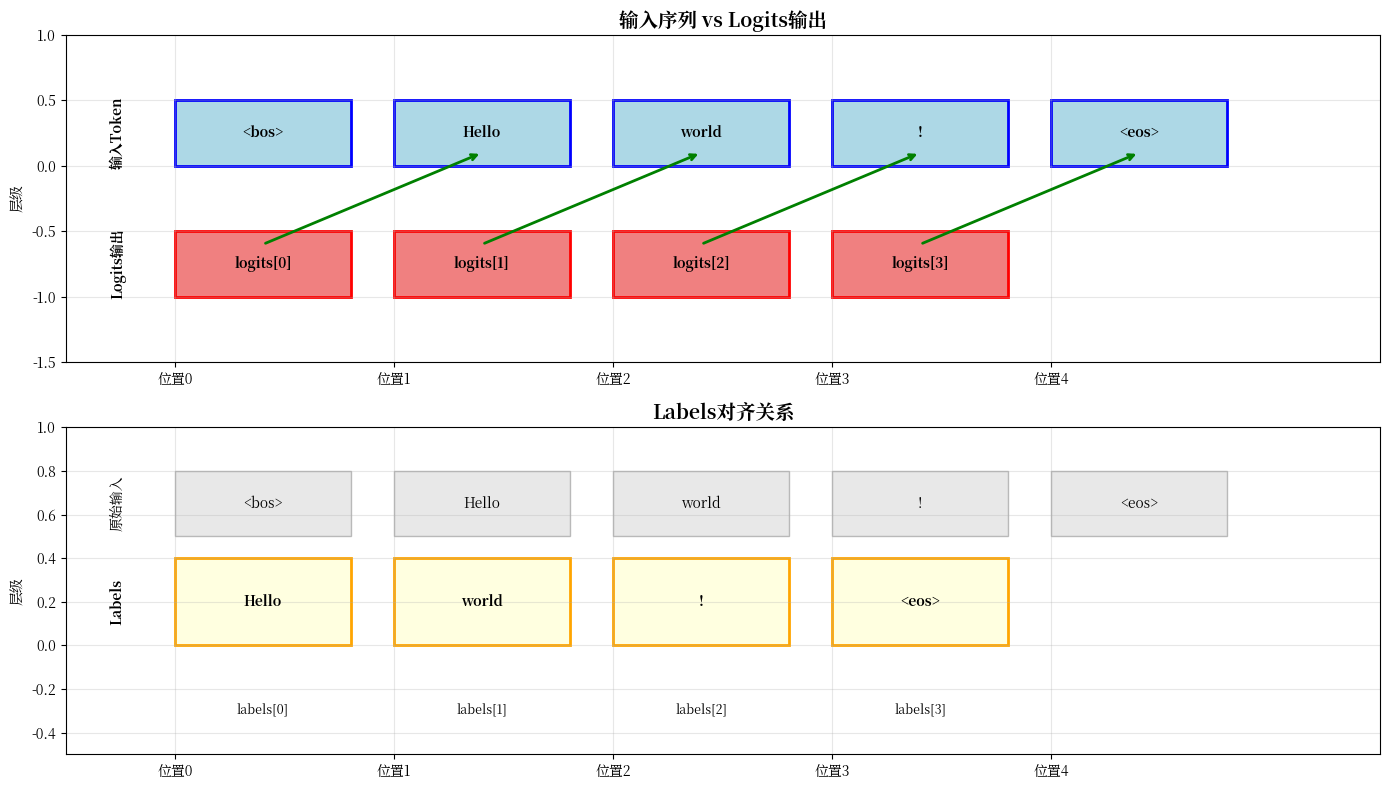

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_alignment():
    """可视化logits和labels的对齐关系"""
    
    plt.rcParams['font.family'] = ['Source Han Serif CN']
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # 示例数据
    tokens = ["<bos>", "Hello", "world", "!", "<eos>"]
    positions = list(range(len(tokens)))
    
    # 上图：输入序列和logits
    ax1.set_title("输入序列 vs Logits输出", fontsize=14, fontweight='bold')
    
    # 绘制输入token
    for i, token in enumerate(tokens):
        rect = patches.Rectangle((i, 0), 0.8, 0.5, linewidth=2, 
                               edgecolor='blue', facecolor='lightblue')
        ax1.add_patch(rect)
        ax1.text(i + 0.4, 0.25, token, ha='center', va='center', fontweight='bold')
    
    # 绘制logits输出（少一个）
    for i in range(len(tokens) - 1):
        rect = patches.Rectangle((i, -1), 0.8, 0.5, linewidth=2, 
                               edgecolor='red', facecolor='lightcoral')
        ax1.add_patch(rect)
        ax1.text(i + 0.4, -0.75, f"logits[{i}]", ha='center', va='center', fontweight='bold')
        
        # 绘制箭头表示预测关系
        ax1.annotate('', xy=(i + 1.4, 0.1), xytext=(i + 0.4, -0.6),
                    arrowprops=dict(arrowstyle='->', color='green', lw=2))
    
    ax1.set_xlim(-0.5, len(tokens) + 0.5)
    ax1.set_ylim(-1.5, 1)
    ax1.set_ylabel("层级")
    ax1.text(-0.3, 0.25, "输入Token", rotation=90, va='center', fontweight='bold')
    ax1.text(-0.3, -0.75, "Logits输出", rotation=90, va='center', fontweight='bold')
    ax1.set_xticks(positions)
    ax1.set_xticklabels([f"位置{i}" for i in positions])
    ax1.grid(True, alpha=0.3)
    
    # 下图：labels对齐
    ax2.set_title("Labels对齐关系", fontsize=14, fontweight='bold')
    
    # 绘制完整输入序列（参考）
    for i, token in enumerate(tokens):
        rect = patches.Rectangle((i, 0.5), 0.8, 0.3, linewidth=1, 
                               edgecolor='gray', facecolor='lightgray', alpha=0.5)
        ax2.add_patch(rect)
        ax2.text(i + 0.4, 0.65, token, ha='center', va='center', fontsize=10)
    
    # 绘制labels（从位置1开始）
    for i in range(1, len(tokens)):
        rect = patches.Rectangle((i-1, 0), 0.8, 0.4, linewidth=2, 
                               edgecolor='orange', facecolor='lightyellow')
        ax2.add_patch(rect)
        ax2.text(i-1 + 0.4, 0.2, tokens[i], ha='center', va='center', fontweight='bold')
        
        # 标注这是labels的哪个位置
        ax2.text(i-1 + 0.4, -0.3, f"labels[{i-1}]", ha='center', va='center', 
                fontsize=9, style='italic')
    
    ax2.set_xlim(-0.5, len(tokens) + 0.5)
    ax2.set_ylim(-0.5, 1)
    ax2.set_ylabel("层级")
    ax2.text(-0.3, 0.65, "原始输入", rotation=90, va='center', fontsize=10)
    ax2.text(-0.3, 0.2, "Labels", rotation=90, va='center', fontweight='bold')
    ax2.set_xticks(positions)
    ax2.set_xticklabels([f"位置{i}" for i in positions])
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 运行可视化
visualize_alignment()


In [19]:
def explain_your_code():
    """解释你的代码中的具体操作"""
    
    print("🔍 你的代码分析")
    print("="*50)
    
    # 模拟你的数据
    batch_size, seq_len, vocab_size = 2, 6, 1000
    
    # 1. 模型输出
    logits = torch.randn(batch_size, seq_len, vocab_size)
    print(f"📊 原始logits: {logits.shape}")
    print(f"   含义: 每个位置对所有vocab的预测分数")
    
    # 2. 去掉最后一个位置的logits
    prediction_logits = logits[:, :-1, :]
    print(f"📊 prediction_logits: {prediction_logits.shape}")
    print(f"   含义: 用于预测的logits（最后位置无需预测）")
    
    # 3. 输入序列
    input_ids = torch.randint(0, vocab_size, (batch_size, seq_len))
    print(f"📊 input_ids: {input_ids.shape}")
    print(f"   含义: 完整的输入token序列")
    
    # 4. 标签（预测目标）
    labels = input_ids[:, 1:]
    print(f"📊 labels: {labels.shape}")
    print(f"   含义: 预测目标（去掉第一个token）")
    
    print(f"\n🎯 对应关系:")
    print(f"   logits[i] 预测 labels[i]")
    print(f"   logits[0] 预测 labels[0] (即input_ids[1])")
    print(f"   logits[1] 预测 labels[1] (即input_ids[2])")
    print(f"   ...")
    print(f"   logits[{seq_len-2}] 预测 labels[{seq_len-2}] (即input_ids[{seq_len-1}])")
    
    # 5. 转换为对数概率
    logp = torch.nn.functional.log_softmax(prediction_logits, dim=-1)
    print(f"\n📊 logp: {logp.shape}")
    print(f"   含义: 每个位置的对数概率分布")
    
    # 6. 提取实际token的概率
    selected_logp = torch.gather(logp, 2, labels.unsqueeze(-1)).squeeze(-1)
    print(f"📊 selected_logp: {selected_logp.shape}")
    print(f"   含义: 每个位置实际token的对数概率")
    
    print(f"\n✨ 总结:")
    print(f"   - logits[:, :-1, :]: 去掉最后位置，因为它没有下一个token可预测")
    print(f"   - labels = input_ids[:, 1:]: 去掉第一个token，因为它不是任何位置的预测目标")
    print(f"   - 这样确保了 logits[i] 对应预测 labels[i]")

# 运行解释
explain_your_code()


🔍 你的代码分析
📊 原始logits: torch.Size([2, 6, 1000])
   含义: 每个位置对所有vocab的预测分数
📊 prediction_logits: torch.Size([2, 5, 1000])
   含义: 用于预测的logits（最后位置无需预测）
📊 input_ids: torch.Size([2, 6])
   含义: 完整的输入token序列
📊 labels: torch.Size([2, 5])
   含义: 预测目标（去掉第一个token）

🎯 对应关系:
   logits[i] 预测 labels[i]
   logits[0] 预测 labels[0] (即input_ids[1])
   logits[1] 预测 labels[1] (即input_ids[2])
   ...
   logits[4] 预测 labels[4] (即input_ids[5])

📊 logp: torch.Size([2, 5, 1000])
   含义: 每个位置的对数概率分布
📊 selected_logp: torch.Size([2, 5])
   含义: 每个位置实际token的对数概率

✨ 总结:
   - logits[:, :-1, :]: 去掉最后位置，因为它没有下一个token可预测
   - labels = input_ids[:, 1:]: 去掉第一个token，因为它不是任何位置的预测目标
   - 这样确保了 logits[i] 对应预测 labels[i]
